# Example: Compare Ground Measurements with CAMS CRS Satellite Data
### 示例：对比地面观测与 CAMS CRS 卫星数据

This notebook demonstrates reading BSRN station data, adding REST2 clear-sky references (from MERRA-2 HF), running the QC suite, adding CRS satellite data (from HF), calculating solar geometry, and performing time averaging.

本手册演示读取 BSRN 站点数据、添加 REST2 晴空参考（来自 MERRA-2 HF）、运行 QC、添加 CRS 卫星数据（来自 HF）、计算太阳几何以及执行时间平均。

In [1]:
import os
import pandas as pd
import bsrn
import bsrn.visualization.calendar

# For inline plotting in some environments
%matplotlib inline

## 1. Parameters / 参数设置

In [2]:
station_code = "QIQ"
INPUT_FILE = "/Volumes/Macintosh Research/Data/bsrn-qc/data/QIQ/qiq0824.dat.gz"

print(f"--- Processing {station_code} for Aug 2024 ---")

--- Processing QIQ for Aug 2024 ---


## 2. Load Data and Add Clear-sky / 加载数据与添加晴空模型

In [3]:
if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(f"File not found: {INPUT_FILE}")

df = bsrn.io.readers.read_station_to_archive(INPUT_FILE, logical_records="lr0100")
print(f"Loaded {len(df)} rows from archive.")

print("Fetching MERRA-2 and adding REST2 clear-sky columns...")
df = bsrn.modeling.clear_sky.add_clearsky_columns(df, station_code=station_code, model="rest2")

Loaded 44640 rows from archive.
Fetching MERRA-2 and adding REST2 clear-sky columns...
Fetching MERRA-2 from Hugging Face: qiq/qiq0824_merra2.parquet


## 3. QC and Pre-processing / 质量控制与预处理

In [4]:
print("Running QC suite...")
df = bsrn.qc.wrapper.run_qc(df, station_code=station_code)

print("Calculating solar geometry...")
meta = bsrn.constants.BSRN_STATIONS[station_code]
lat, lon, elev = meta["lat"], meta["lon"], meta["elev"]
solpos = bsrn.physics.geometry.get_solar_position(df.index, lat, lon, elev)
df["zenith"] = solpos["zenith"]

Running QC suite...
Calculating solar geometry...


## 4. Time Averaging and CRS Satellite Data / 时间平均与 CRS 卫星数据

In [5]:
print("Performing 1-hour time averaging...")
df_avg = bsrn.utils.pretty_average(df, rule="1h", alignment="ceiling")

print("Fetching and adding CRS all-sky columns...")
df_avg = bsrn.io.crs.add_crs_columns(df_avg, station_code=station_code)

df_avg.head()

Performing 1-hour time averaging...
Fetching and adding CRS all-sky columns...
Fetching CRS from Hugging Face: qiq/qiq0824_crs.parquet


,ghi,bni,dhi,lwd,temp,rh,pressure,ghi_clear,bni_clear,dhi_clear,...,flagKlowSZA,flagKhighSZA,flagKbKt,flagKb,flagKt,flagTracker,zenith,ghi_crs,bni_crs,dhi_crs
2024-08-01 01:00:00+00:00,216.133333,1.583333,217.000000,422.683333,24.951667,70.116667,981.100000,581.242207,698.516922,131.990749,...,0.0,0.0,0.0,0.0,0.0,0.050000,49.990336,234.8583,20.1304,220.9897
2024-08-01 02:00:00+00:00,408.266667,12.750000,402.983333,424.466667,24.091667,72.616667,981.833333,706.014880,752.550654,138.728785,...,0.0,0.0,0.0,0.0,0.0,0.233333,41.060464,435.8102,109.2258,354.3260
2024-08-01 03:00:00+00:00,303.216667,1.516667,304.600000,427.050000,23.093333,76.166667,982.000000,791.169867,781.591286,143.379628,...,0.0,0.0,0.0,0.0,0.0,0.000000,33.993903,379.7638,38.4415,347.7802
2024-08-01 04:00:00+00:00,230.416667,1.000000,231.850000,429.716667,22.895000,75.783333,982.300000,826.488990,775.688256,156.927791,...,0.0,0.0,0.0,0.0,0.0,0.000000,30.319931,350.2391,18.1016,334.6695
2024-08-01 05:00:00+00:00,237.150000,1.000000,238.466667,431.250000,22.560000,78.816667,983.000000,817.448071,776.621555,153.959315,...,0.0,0.0,0.0,0.0,0.0,0.000000,31.301788,357.3329,20.2727,340.1166


## 5. Visualization / 可视化对比

/Volumes/Macintosh Research/Data/bsrn-qc/src/bsrn/visualization/calendar.py:85: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/geoms/geom_path.py:112: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


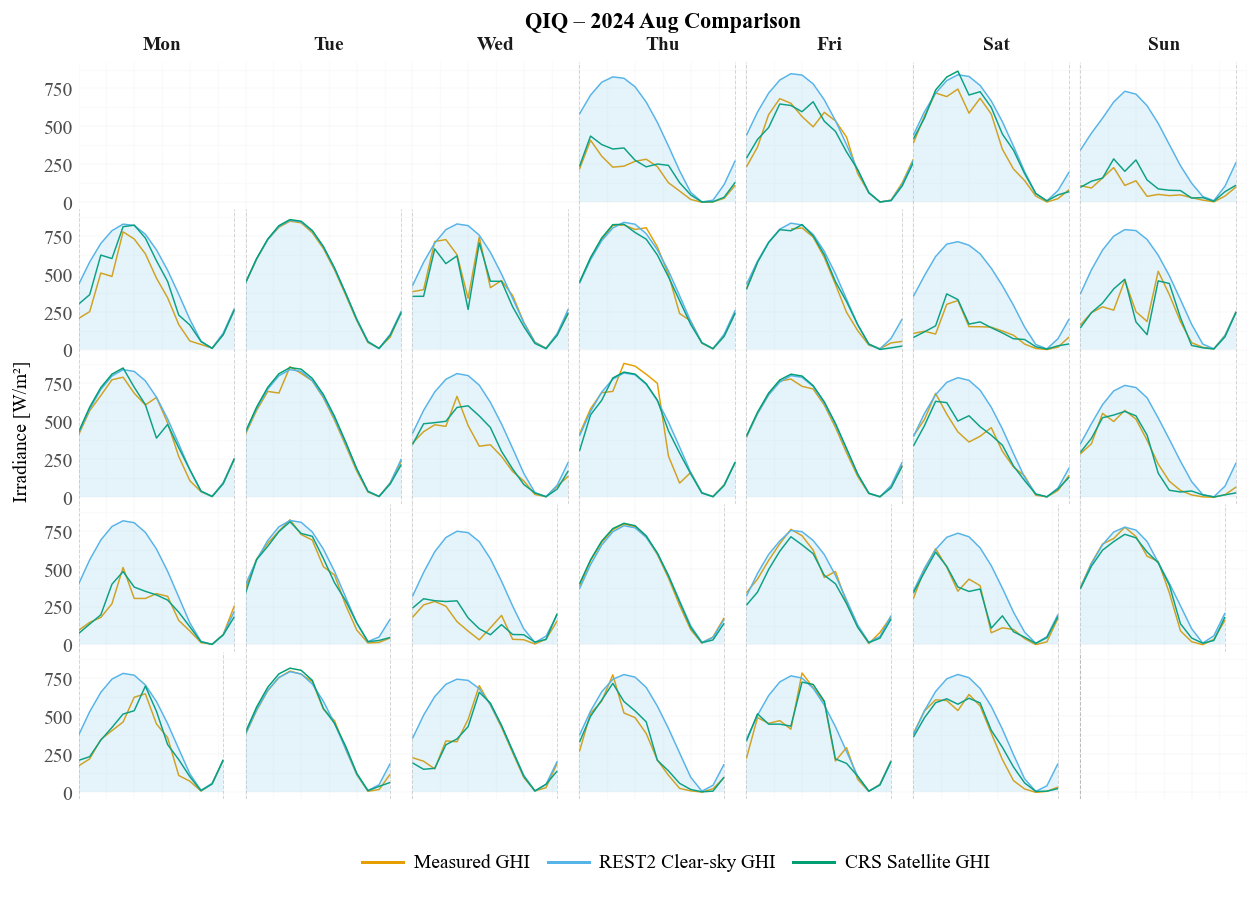

In [6]:
p = bsrn.visualization.calendar.plot_calendar(
    df=df_avg,
    output_file=None, # Display inline instead of saving / 仅在线显示不保存文件
    station_code=station_code,
    meas_col='ghi',
    clear_col='ghi_clear',
    other_cols=['ghi_crs'],
    labels=['Measured GHI', 'REST2 Clear-sky GHI', 'CRS Satellite GHI'],
)

p